In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision as vision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from helper_functions import *

import kagglehub as kg

from tqdm.auto import tqdm # Progress bar
from pathlib import Path
import zipfile
from PIL import Image
import random

torch.set_default_device("cpu")

print(f"Torch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"KaggleHub: {kg.__version__}")

!nvidia-smi

Torch: 2.7.1
TorchVision: 0.22.1
KaggleHub: 0.3.12
zsh:1: command not found: nvidia-smi


In [8]:
data_path = Path("./")
image_path = data_path / Path("pizza_steak_sushi")
if image_path.is_dir():
    print("Images already downloaded")

Images already downloaded


In [9]:
# We need to cretate a custom dataset e we need to perform some transformations on the data
# Lets try FoodVisionMini

# Load custom data
# We need to transform data into tensors
import os
def walk_through_dir(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories {len(filenames)}")

In [10]:
walk_through_dir("pizza_steak_sushi")

There are 2 directories 0
There are 3 directories 0
There are 0 directories 58
There are 0 directories 46
There are 0 directories 46
There are 3 directories 0
There are 0 directories 146
There are 0 directories 150
There are 0 directories 154


In [12]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir, test_dir

(PosixPath('pizza_steak_sushi/train'), PosixPath('pizza_steak_sushi/test'))

In [15]:
# Lets visualize the data
random.seed(42)

# Pattern for selecting the names
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('pizza_steak_sushi/test/steak/413497.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2246332.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2475366.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/1982192.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2353677.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/1166047.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/1848936.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/3497585.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/1335842.jpg'),
 PosixPath('pizza_steak_sushi/test/steak/2752603.jpg')]

R image path: pizza_steak_sushi/test/pizza/930553.jpg
R image class: pizza
R image dim: 512 306


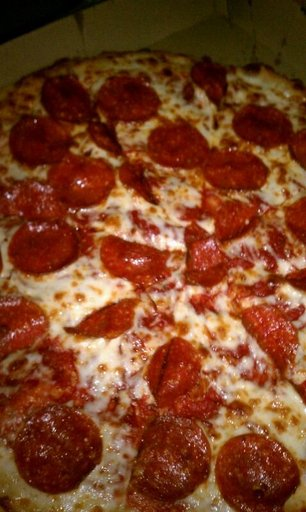

In [31]:
# Open image
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print(f"R image path: {random_image_path}")
print(f"R image class: {image_class}")
print(f"R image dim: {img.height} {img.width}")
img

Text(0.5, 1.0, 'Class: pizza | shape: (512, 306, 3) | h X w: 512 X 306')

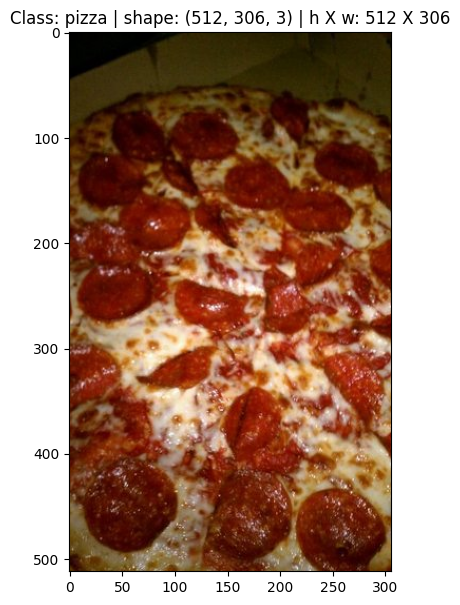

In [32]:
# Tunn image into array
img_as_array = np.asarray(img)
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Class: {image_class} | shape: {img_as_array.shape} | h X w: {img.height} X {img.width}")

In [ ]:
# Transforming data
# We need to trasform data into tensors
# From data -> dataset -> dataloader

